# Credit Card Default: SHAP vs LIME

**Dataset:** Taiwan Credit Card Default (UCI / OpenML `350`)

30,000 clients with repayment history, bill statements, and demographics (Apr–Sep 2005).

| Target | Meaning |
|--------|---------|
| **0** | No default next month |
| **1** | Default next month |

We train a logistic regression model and compare **SHAP** and **LIME** explanations on the same prediction.

> Column names follow the UCI documentation. OpenML exposes these as `x1`–`x23`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

# OpenML x1-x23 map directly to UCI X1-X23 (dataset description)
COLUMN_MAP = {
    "x1": "limit_bal",
    "x2": "sex",
    "x3": "education",
    "x4": "marriage",
    "x5": "age",
    "x6": "pay_0", 
    "x7": "pay_2", 
    "x8": "pay_3", 
    "x9": "pay_4",
    "x10": "pay_5", 
    "x11": "pay_6",
    "x12": "bill_amt1", 
    "x13": "bill_amt2", 
    "x14": "bill_amt3",
    "x15": "bill_amt4", 
    "x16": "bill_amt5", 
    "x17": "bill_amt6",
    "x18": "pay_amt1", 
    "x19": "pay_amt2", 
    "x20": "pay_amt3",
    "x21": "pay_amt4", 
    "x22": "pay_amt5", 
    "x23": "pay_amt6",
}

raw = fetch_openml(data_id=42477, as_frame=True, parser="auto")
X = raw.data.rename(columns=COLUMN_MAP)
y = raw.target.astype(int)

CLASS_NAMES = ["No Default", "Default"]

print(f"Clients: {len(X)}")
print(f"Default rate: {y.mean():.1%}")
print(f"Features: {X.shape[1]}")
print(f"Age range: {X['age'].min()} - {X['age'].max()}")
print()
display(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nTop 5 coefficients by |value|:")
print(coefs.head(5).to_string())

Clients: 30000
Default rate: 22.1%
Features: 23
Age range: 21 - 79



,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



Accuracy: 0.680
              precision    recall  f1-score   support

  No Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000


Top 5 coefficients by |value|:
pay_0        0.590401
bill_amt1   -0.285129
pay_amt1    -0.184401
pay_amt2    -0.161328
limit_bal   -0.136720


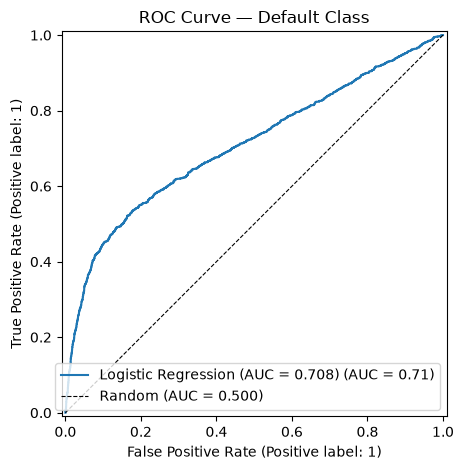

In [2]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_probability)

RocCurveDisplay.from_predictions(
    y_test, y_probability,
    name=f"Logistic Regression (AUC = {auc:.3f})",
)
plt.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC = 0.500)")
plt.title("ROC Curve — Default Class")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Background dataset has 24000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24000 when initializing the masker.


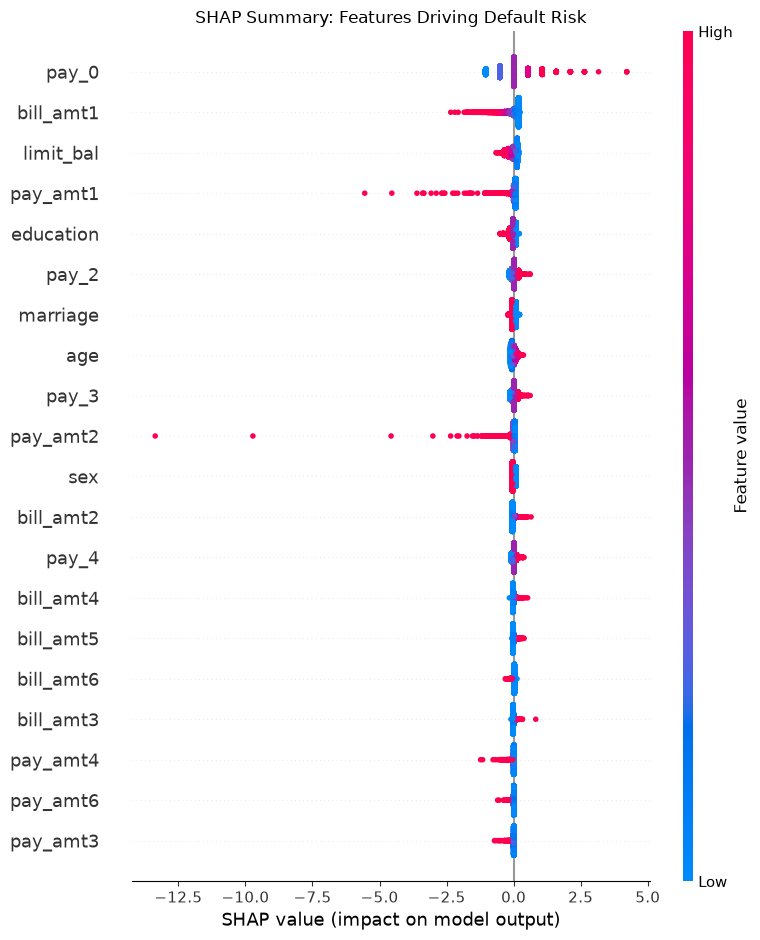

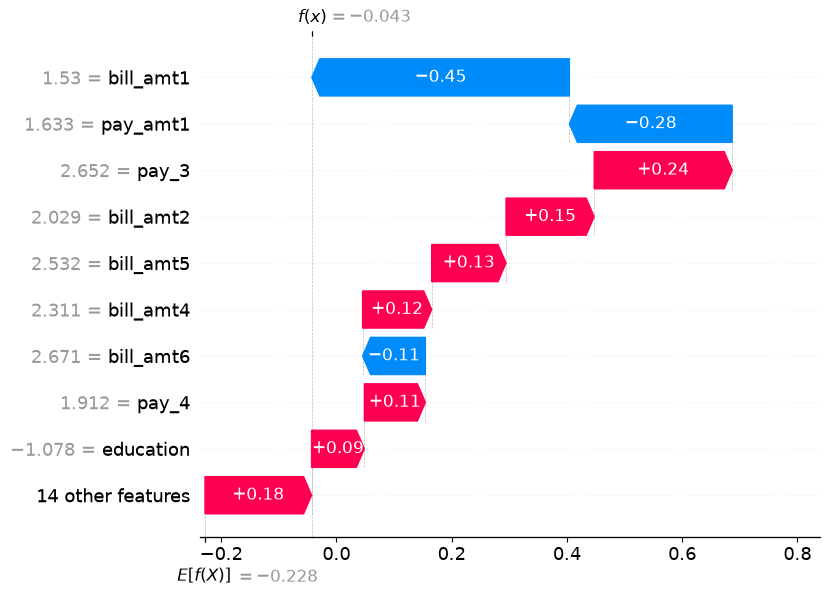

In [3]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

explainer = shap.LinearExplainer(model, X_train_scaled)
X_shap = X_test_scaled.sample(6000, random_state=42)
explanation = explainer(X_shap)

shap.summary_plot(explanation, show=False)
plt.title("SHAP Summary: Features Driving Default Risk")
plt.tight_layout()
plt.show()

sample_idx = 0
shap.waterfall_plot(explanation[sample_idx])

/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


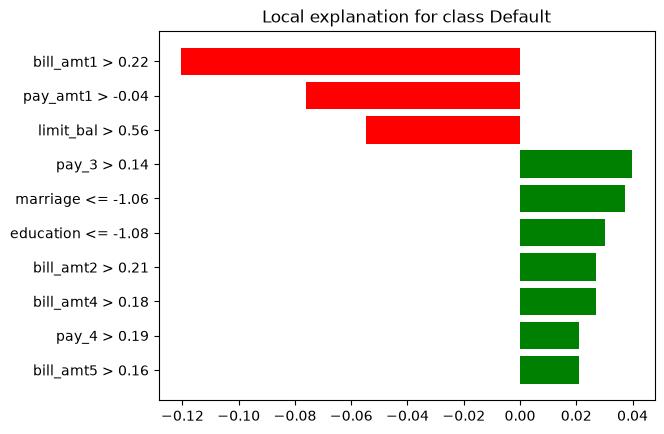

In [4]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X.columns.tolist(),
    class_names=CLASS_NAMES,
    mode="classification",
    random_state=42,
)

sample_idx = 0
exp = lime_explainer.explain_instance(
    X_shap.iloc[sample_idx].values,
    model.predict_proba,
    num_features=10,
)
exp.as_pyplot_figure()
plt.show()

Client #0 prediction: No Default

             SHAP    LIME
bill_amt1 -0.4469 -0.1204
pay_amt1  -0.2825 -0.0762
pay_3      0.2395  0.0399
bill_amt2  0.1530  0.0270
bill_amt5  0.1290  0.0210
bill_amt4  0.1199  0.0269
limit_bal -0.0904 -0.0548
pay_4      0.1059  0.0211
education  0.0916  0.0301
marriage   0.0773  0.0375

Sign agreement: 100%


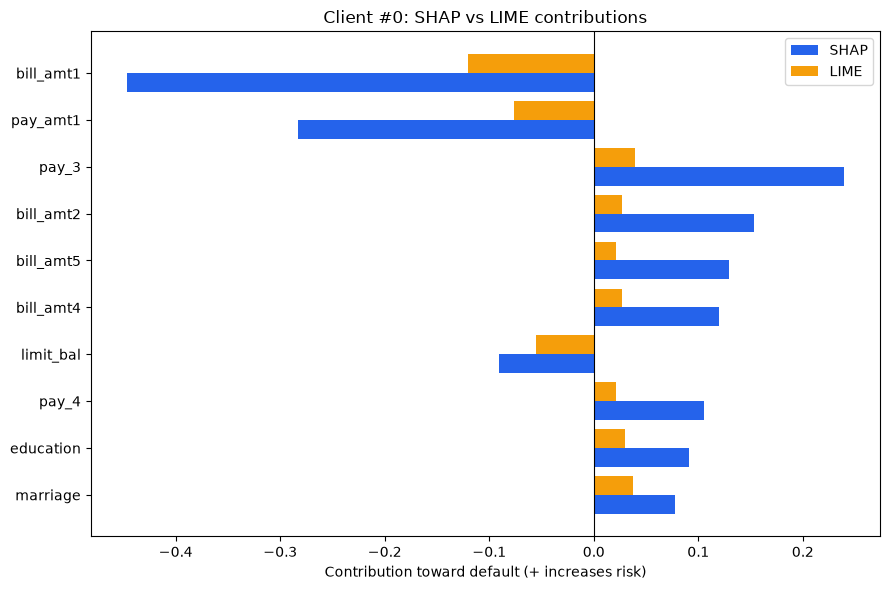

In [5]:
shap_vals = pd.Series(explanation[sample_idx].values, index=X.columns)

lime_map = dict(exp.as_map()[1])  # class 1 = Default
lime_vals = pd.Series({X.columns[i]: w for i, w in lime_map.items()})

cmp = pd.DataFrame({"SHAP": shap_vals, "LIME": lime_vals}).dropna(subset=["LIME"])
cmp["importance"] = cmp.abs().mean(axis=1)
cmp = cmp.sort_values("importance", ascending=False).drop(columns="importance")

decision = CLASS_NAMES[model.predict(X_shap.iloc[[sample_idx]])[0]]
print(f"Client #{sample_idx} prediction: {decision}\n")
print(cmp.round(4).to_string())

agreement = (np.sign(cmp["SHAP"]) == np.sign(cmp["LIME"])).mean()
print(f"\nSign agreement: {agreement:.0%}")

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(cmp))
ax.barh(y_pos + 0.2, cmp["SHAP"], height=0.4, label="SHAP", color="#2563eb")
ax.barh(y_pos - 0.2, cmp["LIME"], height=0.4, label="LIME", color="#f59e0b")
ax.set_yticks(y_pos)
ax.set_yticklabels(cmp.index)
ax.axvline(0, color="black", lw=0.8)
ax.invert_yaxis()
ax.legend()
ax.set_title(f"Client #{sample_idx}: SHAP vs LIME contributions")
ax.set_xlabel("Contribution toward default (+ increases risk)")
plt.tight_layout()
plt.show()

## SHAP vs LIME

| | SHAP | LIME |
|---|------|------|
| Idea | Shapley values | Local linear surrogate around one prediction |
| Scope | Global + local | Local only |
| Theory | Local accuracy + consistency axioms | Approximation, no global guarantee |
| Stability | Deterministic | Depends on random perturbations |
| Speed | Fast for linear models | Generally fast |
| Scale | Additive in model output space | Local coefficients, not guaranteed to sum to prediction |

Both methods highlight repayment status (`pay_*`) and bill/payment amounts as the main drivers. Sign agreement is strong on the top features; small differences on low-importance variables are expected because LIME samples locally.